# High Frequency Data and Limit Order Books
## Lab 6: DeFi

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

In [6]:
df = pd.read_csv('Data/uniswap_v3.csv.gz')
df.head()

,amount0,amount1,amountUSD,id,logIndex,origin,recipient,sender,sqrtPriceX96,tick,...,owner,tickLower,tickUpper,transaction.blockNumber,transaction.gasPrice,transaction.gasUsed,transaction.id,transaction.timestamp,price_1_per_0,t
0,-10.000000,0.003023,9.998842,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,264,0x12f82b9929c92fdf853d9d9b076c32909f25718a,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,1377282103516700331802368117587827,195275.0,...,NaN,NaN,NaN,24257914,1.033162e+09,0.0,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,1768694459,3.021771e+08,59.0
1,0.002699,-8.929703,8.927690,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,221,0x3bae26c9ee93467619ebb3d0dbc3d052243cacb4,0xcdb49866c473bfd0a4dbf64e48d7db2cd31796df,0x8793c6aa63cc96c955da4906f628dc09cd595dc8,4558100686673991521600072,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,1768694471,3.309649e-09,71.0
2,0.001749,-5.785837,5.784533,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,288,0x19a4cc064ba710a9ce97499f3c659288bb2ad2dd,0x0b02428e7c2c24ccf64426e637aee0c879bd1860,0x40753445cc591925b49a00d5d727a4fd7049d800,4558100464914553349295265,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,1768694471,3.309649e-09,71.0
3,0.000000,0.000000,0.000000,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,394,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257915,NaN,NaN,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,1768694471,NaN,71.0
4,0.000000,0.000000,0.000000,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,311,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257916,NaN,NaN,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,1768694483,NaN,83.0


---
1. Explore the proposed dataset. Comment, explain.

In [7]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
df.head(3)

Shape: (468192, 24)

Columns: ['amount0', 'amount1', 'amountUSD', 'id', 'logIndex', 'origin', 'recipient', 'sender', 'sqrtPriceX96', 'tick', 'timestamp', 'pool', 'event_type', 'amount', 'owner', 'tickLower', 'tickUpper', 'transaction.blockNumber', 'transaction.gasPrice', 'transaction.gasUsed', 'transaction.id', 'transaction.timestamp', 'price_1_per_0', 't']

Dtypes:
amount0                    float64
amount1                    float64
amountUSD                  float64
id                             str
logIndex                     int64
origin                         str
recipient                      str
sender                         str
sqrtPriceX96                object
tick                       float64
timestamp                      str
pool                           str
event_type                     str
amount                     float64
owner                          str
tickLower                  float64
tickUpper                  float64
transaction.blockNumber      int64
t

,amount0,amount1,amountUSD,id,logIndex,origin,recipient,sender,sqrtPriceX96,tick,...,owner,tickLower,tickUpper,transaction.blockNumber,transaction.gasPrice,transaction.gasUsed,transaction.id,transaction.timestamp,price_1_per_0,t
0,-10.000000,0.003023,9.998842,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,264,0x12f82b9929c92fdf853d9d9b076c32909f25718a,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,1377282103516700331802368117587827,195275.0,...,NaN,NaN,NaN,24257914,1.033162e+09,0.0,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,1768694459,3.021771e+08,59.0
1,0.002699,-8.929703,8.927690,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,221,0x3bae26c9ee93467619ebb3d0dbc3d052243cacb4,0xcdb49866c473bfd0a4dbf64e48d7db2cd31796df,0x8793c6aa63cc96c955da4906f628dc09cd595dc8,4558100686673991521600072,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,1768694471,3.309649e-09,71.0
2,0.001749,-5.785837,5.784533,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,288,0x19a4cc064ba710a9ce97499f3c659288bb2ad2dd,0x0b02428e7c2c24ccf64426e637aee0c879bd1860,0x40753445cc591925b49a00d5d727a4fd7049d800,4558100464914553349295265,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,1768694471,3.309649e-09,71.0


In [8]:
print(f"Event types:\n{df['event_type'].value_counts()}")
print(f"\nPools:\n{df['pool'].value_counts()}")
print(f"\nTime range: {pd.to_datetime(df['transaction.timestamp'], unit='s').min()} to {pd.to_datetime(df['transaction.timestamp'], unit='s').max()}")
print(f"\nUnique transactions: {df['transaction.id'].nunique()}")
print(f"Unique origins (wallets): {df['origin'].nunique()}")

Event types:
event_type
swap    448989
burn     10036
mint      9167
Name: count, dtype: int64

Pools:
pool
0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640    230249
0x11b815efb8f581194ae79006d24e0d814b7697f6    151283
0x3416cf6c708da44db2624d63ea0aaef7113527c6     45334
0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8     27757
0xcbcdf9626bc03e24f779434178a73a0b4bad62ed     13569
Name: count, dtype: int64

Time range: 2026-01-18 00:00:59 to 2026-02-16 23:59:59

Unique transactions: 398708
Unique origins (wallets): 66370


In [9]:
print(f"amountUSD stats:\n{df['amountUSD'].describe()}")
print(f"\namountUSD by event type:")
print(df.groupby('event_type')['amountUSD'].describe())

amountUSD stats:
count    4.681920e+05
mean     3.233954e+04
std      2.054228e+05
min      0.000000e+00
25%      1.531563e+02
50%      1.915756e+03
75%      8.548032e+03
max      2.582459e+07
Name: amountUSD, dtype: float64

amountUSD by event type:
               count           mean            std           min         25%  \
event_type                                                                     
burn         10036.0  344655.083200  865313.593970  0.000000e+00    0.000000   
mint          9167.0  375989.112418  878339.221192  1.000000e-06  302.291729   
swap        448989.0   18342.241158   82044.006646  1.900000e-15  161.472082   

                    50%            75%           max  
event_type                                            
burn         738.272030   60707.561283  2.580929e+07  
mint        2371.713814  117792.426663  2.582459e+07  
swap        1918.462616    8250.266972  1.008026e+07  


In [10]:
# Map pool addresses to known Uniswap V3 pairs
pool_names = {
    '0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640': 'USDC/WETH 0.05%',
    '0x11b815efb8f581194ae79006d24e0d814b7697f6': 'WETH/USDT 0.05%',
    '0x3416cf6c708da44db2624d63ea0aaef7113527c6': 'USDT/USDC 0.01%',
    '0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8': 'USDC/WETH 0.3%',
    '0xcbcdf9626bc03e24f779434178a73a0b4bad62ed': 'WBTC/WETH 0.3%'
}
df['pool_name'] = df['pool'].map(pool_names)
df['datetime'] = pd.to_datetime(df['transaction.timestamp'], unit='s')

# Events per pool per type
print(df.groupby(['pool_name', 'event_type']).size().unstack(fill_value=0))
print(f"\nTotal USD volume by pool:")
print(df.groupby('pool_name')['amountUSD'].sum().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

event_type       burn  mint    swap
pool_name                          
USDC/WETH 0.05%  4253  4624  221372
USDC/WETH 0.3%   1807  1049   24901
USDT/USDC 0.01%  1627  1484   42223
WBTC/WETH 0.3%   1046   972   11551
WETH/USDT 0.05%  1303  1038  148942

Total USD volume by pool:
pool_name
USDC/WETH 0.05%    $8,216,280,134
USDT/USDC 0.01%    $3,335,920,238
WETH/USDT 0.05%    $1,874,836,428
USDC/WETH 0.3%     $1,028,794,327
WBTC/WETH 0.3%       $685,283,996
Name: amountUSD, dtype: str


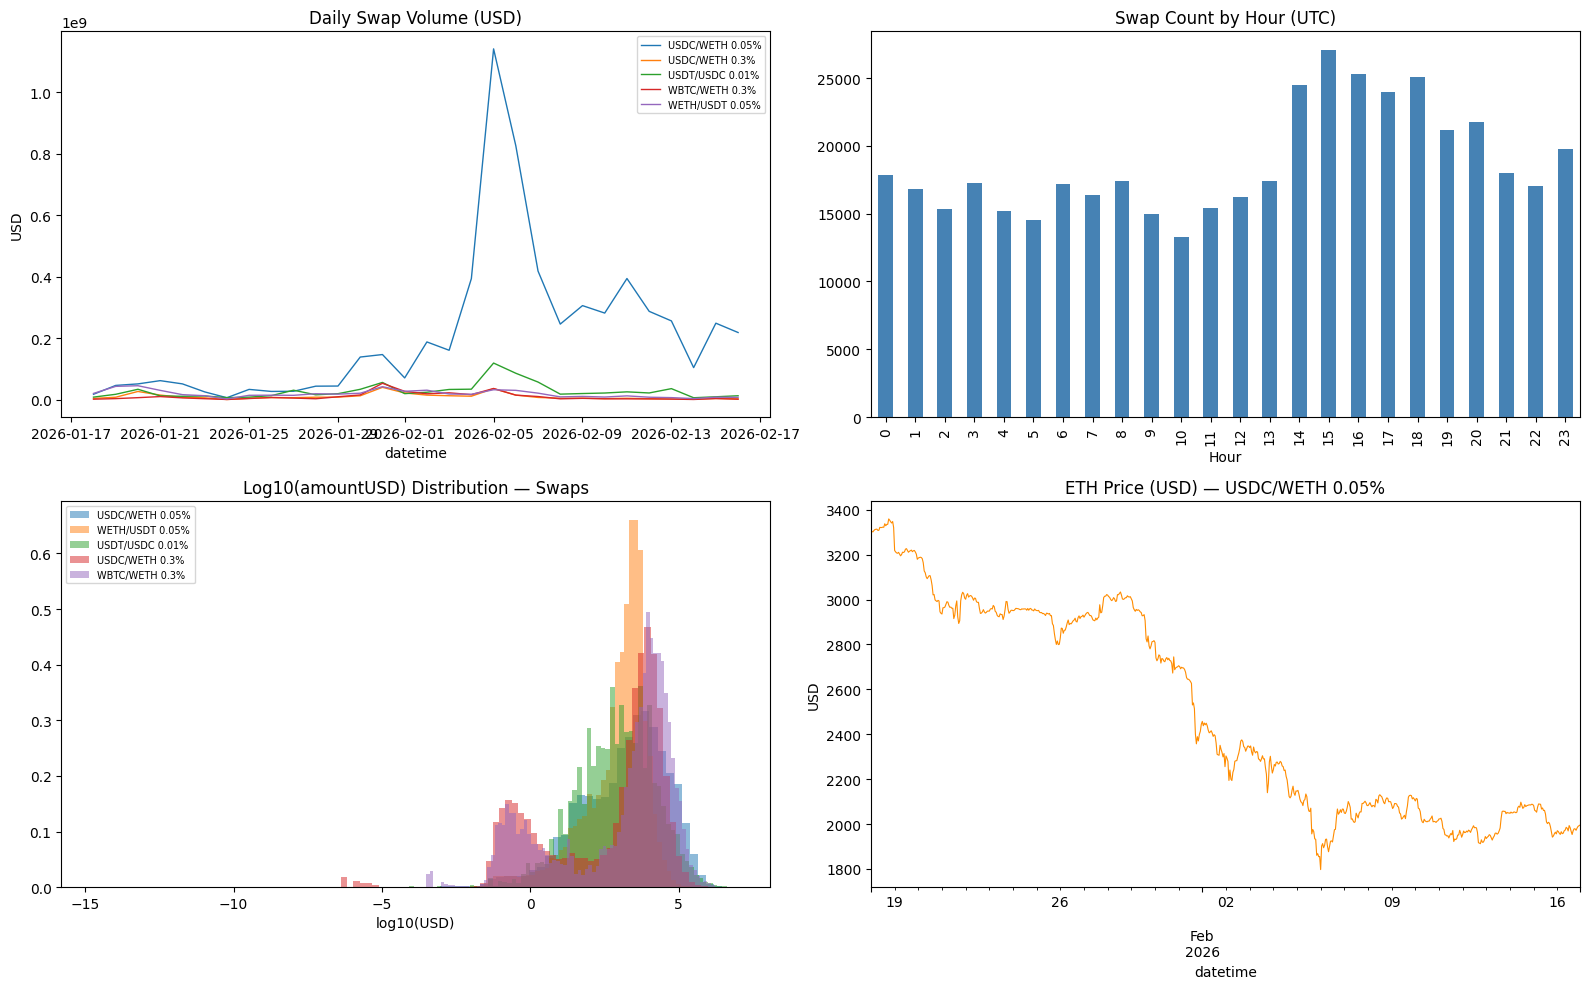

In [ ]:
swaps = df[df['event_type'] == 'swap'].copy()
mints = df[df['event_type'] == 'mint'].copy()
burns = df[df['event_type'] == 'burn'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily swap volume
daily_vol = swaps.groupby([swaps['datetime'].dt.date, 'pool_name'])['amountUSD'].sum().unstack(fill_value=0)
daily_vol.plot(ax=axes[0, 0], linewidth=1)
axes[0, 0].set_title('Daily Swap Volume (USD)')
axes[0, 0].set_ylabel('USD')
axes[0, 0].legend(fontsize=7)

# Hourly swap count
hourly = swaps.groupby(swaps['datetime'].dt.hour).size()
hourly.plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Swap Count by Hour (UTC)')
axes[0, 1].set_xlabel('Hour')

# Log distribution of swap sizes
swaps_pos = swaps[swaps['amountUSD'] > 0]
for pool in swaps_pos['pool_name'].unique():
    subset = swaps_pos[swaps_pos['pool_name'] == pool]['amountUSD']
    axes[1, 0].hist(np.log10(subset), bins=80, alpha=0.5, label=pool, density=True)
axes[1, 0].set_title('Log10(amountUSD) Distribution - Swaps')
axes[1, 0].set_xlabel('log10(USD)')
axes[1, 0].legend(fontsize=7)

# ETH price from USDC/WETH 0.05% pool (token0=USDC 6dec, token1=WETH 18dec)
eth_pool = swaps[swaps['pool_name'] == 'USDC/WETH 0.05%'].copy()
eth_pool = eth_pool.dropna(subset=['price_1_per_0'])
eth_pool = eth_pool.sort_values('datetime')
eth_pool['eth_price'] = 1e12 / eth_pool['price_1_per_0']
eth_pool.set_index('datetime')['eth_price'].resample('1h').median().plot(ax=axes[1, 1], linewidth=0.8, color='darkorange')
axes[1, 1].set_title('ETH Price (USD) - USDC/WETH 0.05%')
axes[1, 1].set_ylabel('USD')

plt.tight_layout()
plt.show()

c:\Users\adoni\Desktop\High-frequency data and limit order books\labs\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\adoni\Desktop\High-frequency data and limit order books\labs\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


Transactions with >1 event: 48533 / 398708 (12.2%)
Max events in a single tx: 48


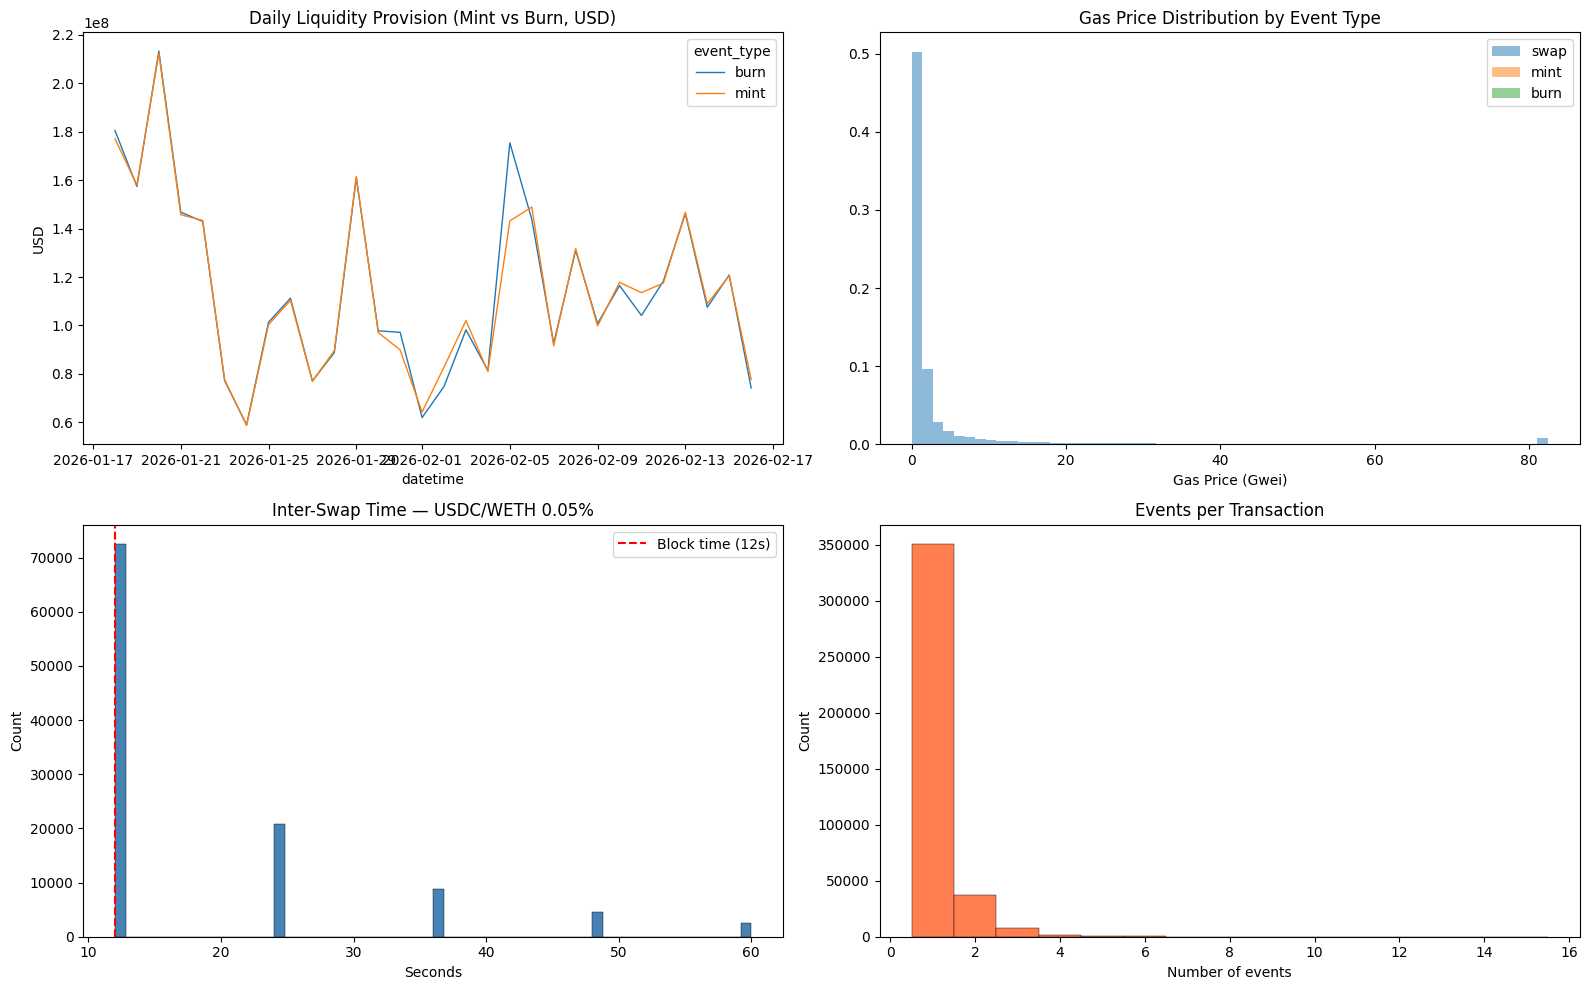

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily mint/burn activity
daily_liq = df[df['event_type'].isin(['mint', 'burn'])].groupby(
    [df['datetime'].dt.date, 'event_type'])['amountUSD'].sum().unstack(fill_value=0)
daily_liq.plot(ax=axes[0, 0], linewidth=1)
axes[0, 0].set_title('Daily Liquidity Provision (Mint vs Burn, USD)')
axes[0, 0].set_ylabel('USD')

# Gas price distribution by event type
gas = df.dropna(subset=['transaction.gasPrice']).copy()
gas['gasGwei'] = gas['transaction.gasPrice'] / 1e9
for et in ['swap', 'mint', 'burn']:
    subset = gas[gas['event_type'] == et]['gasGwei']
    axes[0, 1].hist(subset.clip(upper=subset.quantile(0.99)), bins=60, alpha=0.5, label=et, density=True)
axes[0, 1].set_title('Gas Price Distribution by Event Type')
axes[0, 1].set_xlabel('Gas Price (Gwei)')
axes[0, 1].legend()

# Inter-event times for swaps on USDC/WETH 0.05%
eth_swaps = swaps[swaps['pool_name'] == 'USDC/WETH 0.05%'].sort_values('transaction.timestamp')
iet = eth_swaps['transaction.timestamp'].diff().dropna()
iet = iet[iet > 0]
axes[1, 0].hist(iet[iet <= 60], bins=60, color='steelblue', edgecolor='black', linewidth=0.3)
axes[1, 0].set_title('Inter-Swap Time - USDC/WETH 0.05%')
axes[1, 0].set_xlabel('Seconds')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(12, color='red', linestyle='--', label='Block time (12s)')
axes[1, 0].legend()

# Number of events per transaction
events_per_tx = df.groupby('transaction.id').size()
axes[1, 1].hist(events_per_tx.clip(upper=15), bins=range(1, 17), color='coral', edgecolor='black', linewidth=0.3, align='left')
axes[1, 1].set_title('Events per Transaction')
axes[1, 1].set_xlabel('Number of events')
axes[1, 1].set_ylabel('Count')
print(f"Transactions with >1 event: {(events_per_tx > 1).sum()} / {len(events_per_tx)} ({(events_per_tx > 1).mean()*100:.1f}%)")
print(f"Max events in a single tx: {events_per_tx.max()}")

plt.tight_layout()
plt.show()

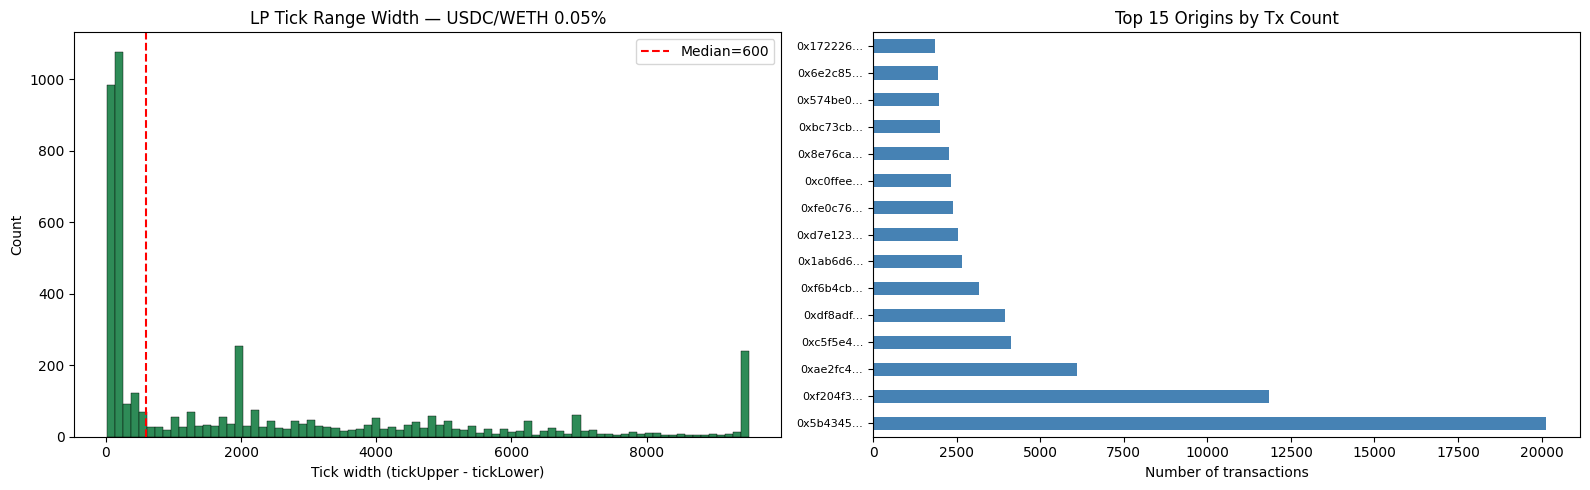


LP position stats (USDC/WETH 0.05%):
  Median tick width: 600
  Mean tick width: 11713
  % narrow range (< 100 ticks): 13.9%
  % full range (width > 800000): 0.5%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tick range width for LP positions (mints)
mints_eth = mints[mints['pool_name'] == 'USDC/WETH 0.05%'].copy()
mints_eth['tick_width'] = mints_eth['tickUpper'] - mints_eth['tickLower']
axes[0].hist(mints_eth['tick_width'].clip(upper=mints_eth['tick_width'].quantile(0.95)),
             bins=80, color='seagreen', edgecolor='black', linewidth=0.3)
axes[0].set_title('LP Tick Range Width - USDC/WETH 0.05%')
axes[0].set_xlabel('Tick width (tickUpper - tickLower)')
axes[0].set_ylabel('Count')
axes[0].axvline(mints_eth['tick_width'].median(), color='red', linestyle='--', label=f'Median={mints_eth["tick_width"].median():.0f}')
axes[0].legend()

# Top 15 origins by number of transactions
top_origins = df.groupby('origin')['transaction.id'].nunique().nlargest(15)
top_origins.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Origins by Tx Count')
axes[1].set_xlabel('Number of transactions')
axes[1].set_ylabel('')
axes[1].set_yticklabels([a[:8] + '...' for a in top_origins.index], fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nLP position stats (USDC/WETH 0.05%):")
print(f"Median tick width: {mints_eth['tick_width'].median():.0f}")
print(f"Mean tick width: {mints_eth['tick_width'].mean():.0f}")
print(f"% narrow range (< 100 ticks): {(mints_eth['tick_width'] < 100).mean()*100:.1f}%")
print(f"% full range (width > 800000): {(mints_eth['tick_width'] > 800000).mean()*100:.1f}%")

### Summary
<blockquote>

Comment.

</blockquote>

---
2. Detect MEV attacks such as JIT liquidity and sandwich attacks. Relate your results to the ones proposed in [4]. Comment, explain.

---
References:

[4] D. M. Di Nosse, F. Gatta, F. Lillo, and S. Jaimungal. “Deviations from Tradition: Stylized Facts in the Era of DeFi”. In: arXiv preprint arXiv:2510.22834 (2025).